# Water Meter Pre-Processing

These scripts extract zip files into same directory as other excel files.  
The script assumes that data files are structured as:

|DATE/TIME    |METER_ID    |VALUE    |
|:------------|------------|--------:|
|2025-05-08 08:00:00	|W-84182910	|65455.12 |
|2025-05-08 08:00:00	|W-51139197	|366414.94|
|2025-05-08 08:00:00	|W-84178630	|238466.65|
|...|...|...|

---

## Step 1.0: Generate a list of ZIP files

In [49]:
# Save State
#import pickle
#with open("meter_data_dict.pkl", "wb") as f:
#    pickle.dump(meter_data_dict, f)

In [20]:
# Generate a list of zip files this directory
! ls *.zip* > ziplist.txt
! cat ziplist.txt

Output1_xlsx.zip
Output2_xlsx.zip
Output3_xlsx.zip


---

## Step 1.1: Extract the Files

In [21]:
import zipfile
import os

# Read list of zip files
with open("ziplist.txt") as f:
    zip_files = [line.strip() for line in f if line.strip()]

# Extract each .zip file to the current directory
for zip_path in zip_files:
    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall()  # Extract to current working directory
            print(f"✅ Extracted: {zip_path}")
    except Exception as e:
        print(f"❌ Failed to extract {zip_path}: {e}")

✅ Extracted: Output1_xlsx.zip
✅ Extracted: Output2_xlsx.zip
✅ Extracted: Output3_xlsx.zip


In [22]:
# Debug - Force memory purge
%reset -f

---

## Step 2.0 : Generate a list of all Excel files to be processed

In [23]:
# Generate a list of Excel files this directory
! ls *.xls* > excellist.txt
! cat excellist.txt

Output1.xlsx
Output2.xlsx
Output3.xlsx


---

## Step 3.0: Backup all the Excel files

The processing script by default, deletes original files, so backup the files.  This part was mostly for testing, the files are not huge, but over time the count will get large. 

In [24]:
# Make backup of original source file(s)
import shutil, os
os.makedirs("backup", exist_ok=True)
# Read the list of Excel files
with open("excellist.txt") as f:
    file_list = [line.strip() for line in f if line.strip()]
[shutil.copy(f, os.path.join("backup", f)) for f in file_list]; # The semi-colon suppresses console output

---

## Step 4.0: Process the individual files

Here we read each file, capture date/time from the first row (the read assumes headers by default), write a copy with filename based on date/time. 

Verify then <font color="red">destroy</font> the original.  This destruction step is optional, just set `delete_original = False` to retain original files.

Report to console the progress.

In [25]:
import pandas as pd
from datetime import datetime
import os

# Toggle to control whether original files are deleted
delete_original = True

# Read list of Excel files
with open("excellist.txt") as f:
    file_list = [line.strip() for line in f if line.strip()]

# Create output folder
output_folder = "processed_files"
os.makedirs(output_folder, exist_ok=True)

for file in file_list:
    try:
        # Read Excel file (header expected)
        df = pd.read_excel(file)
        
        # Extract datetime from first row
        dt_str = str(df.iloc[0, 0])  # assuming datetime is in first column
        try:
            dt = pd.to_datetime(dt_str)
        except Exception as e:
            print(f"⚠️ Failed to parse datetime from {file}: {dt_str}")
            continue
        
        # Format datetime string
        formatted = dt.strftime("%Y%m%d_%H%M")
        
        # Extract meter ID from first row (optional)
        # meter_id = str(df.iloc[0, 1])  # second column assumed to be meter ID
        # filename = f"{formatted}_{meter_id}.csv"
        
        # Construct new filename with fixed suffix
        filename = f"{formatted}_meter.csv"
        
        # Output full path
        output_path = os.path.join(output_folder, filename)
        
        # Write to CSV
        df.to_csv(output_path, index=False)
        print(f"✅ Wrote: {output_path}")
        
        # Delete original if enabled
        if delete_original:
            os.remove(file)
            print(f"🗑️ Deleted original file: {file}")
    
    except Exception as e:
        print(f"❌ Error processing {file}: {e}")

✅ Wrote: processed_files/20220509_0000_meter.csv
🗑️ Deleted original file: Output1.xlsx
✅ Wrote: processed_files/20220509_0800_meter.csv
🗑️ Deleted original file: Output2.xlsx
✅ Wrote: processed_files/20220509_1600_meter.csv
🗑️ Deleted original file: Output3.xlsx


In [26]:
# Debug

---

## Step 5.0: Process output files into a single consolidated file

Now we will read these files into a single dataframe for various further processing.  Note the original files are gone, but the .csv equivalents are retained (unless we want to destroy them too!)

In [27]:
# COMBINE, SORT, GROUP

import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

# ===== CONFIGURATION =====
input_folder = "processed_files"
output_file = "combined_meter_data.csv"
group_by_meter = False
generate_plots = False
plot_output_dir = "meter_plots"

# Create output folder for plots
if generate_plots:
    os.makedirs(plot_output_dir, exist_ok=True)

# ===== READ AND CONCATENATE =====
csv_files = glob.glob(os.path.join(input_folder, "*.csv"))
df_list = [pd.read_csv(f) for f in csv_files]
full_df = pd.concat(df_list, ignore_index=True)
# Save diagnostic raw combined output
full_df.to_csv("combined_raw_unnormalized.csv", index=False)
print("📝 Intermediate combined file saved as 'combined_raw_unnormalized.csv'")

# ===== PARSE DATETIME AND SORT =====
# Assume 1st column is datetime, 2nd is meter ID
full_df.columns = ['datetime', 'meter_id', 'value']  # rename for clarity
#full_df['datetime'] = pd.to_datetime(full_df['datetime'])
full_df['datetime'] = pd.to_datetime(full_df['datetime'], format='mixed', errors='coerce')
full_df_sorted = full_df.sort_values(by='datetime').reset_index(drop=True)


# ===== SAVE COMBINED FILE =====
full_df_sorted.to_csv(output_file, index=False)
print(f"✅ Combined and sorted data saved to '{output_file}'")

📝 Intermediate combined file saved as 'combined_raw_unnormalized.csv'
✅ Combined and sorted data saved to 'combined_meter_data.csv'


---

## Step 6.0:  Check for Duplicate Entries

Check for duplicate entries, datetime && meter_id should be unique - no meter should have two values on the same date/time.

Report existence of duplicates.

In [28]:
# Identify duplicates based on datetime + meter_id
dup_mask = full_df_sorted.duplicated(subset=['datetime', 'meter_id'], keep=False)
duplicates_df = full_df_sorted[dup_mask]

# Group the duplicates
grouped = duplicates_df.groupby('meter_id')
display(grouped.head())

# Count total duplicate rows (both first and subsequent)
num_duplicates = dup_mask.sum()

# Report
if num_duplicates == 0:
    print("✅ No duplicate (datetime, meter_id) pairs found.")
else:
    print(f"⚠️ Found {num_duplicates} duplicate rows with the same (datetime, meter_id) pair.")
    # Show first few duplicates
    display(full_df_sorted[dup_mask].head())

,datetime,meter_id,value
37608,2022-05-09 00:00:00,W-51073534,244936.60
93141,2022-05-09 00:00:00,W-51073534,1511891.50
131059,2022-05-09 08:00:00,W-51073534,244982.80
186539,2022-05-09 08:00:00,W-51073534,1512333.10
187234,2022-05-09 16:00:00,W-51073534,1513662.80
965521,2025-05-11 00:00:00,W-51076373,177418.58
965551,2025-05-11 00:00:00,W-51076373,176856.54
968433,2025-05-11 00:00:00,W-51117382,413381.90
968466,2025-05-11 00:00:00,W-51117382,411528.69
1021888,2025-05-11 00:00:00,W-51086335,1493110.03


⚠️ Found 38 duplicate rows with the same (datetime, meter_id) pair.


,datetime,meter_id,value
37608,2022-05-09 00:00:00,W-51073534,244936.6
93141,2022-05-09 00:00:00,W-51073534,1511891.5
131059,2022-05-09 08:00:00,W-51073534,244982.8
186539,2022-05-09 08:00:00,W-51073534,1512333.1
187234,2022-05-09 16:00:00,W-51073534,1513662.8


---

## Step 6.1:  Export Duplicate Entries for Examination

Can export the duplicates to examine, and help diagnose whats going on.

In [29]:
# Export duplicates for review
duplicates_df.to_csv("duplicate_rows_for_review.csv", index=False)
display(duplicates_df.head(10))
print("📝 Duplicates saved to 'duplicate_rows_for_review.csv' for review.")

,datetime,meter_id,value
37608,2022-05-09 00:00:00,W-51073534,244936.6
93141,2022-05-09 00:00:00,W-51073534,1511891.5
131059,2022-05-09 08:00:00,W-51073534,244982.8
186539,2022-05-09 08:00:00,W-51073534,1512333.1
187234,2022-05-09 16:00:00,W-51073534,1513662.8
254250,2022-05-09 16:00:00,W-51073534,245299.8
310033,2025-05-08 08:00:00,W-51073534,624785.7
377732,2025-05-08 08:00:00,W-51073534,5368384.2
386425,2025-05-08 16:00:00,W-51073534,624843.5
425181,2025-05-08 16:00:00,W-51073534,5369073.9


📝 Duplicates saved to 'duplicate_rows_for_review.csv' for review.


---

## Step 6.2:  Remove Duplicate Entries

A few helper functions to deal with duplicates.  Keeping smallest values duplicate is just an option that I think is useable.  If the meters reset when value passes memory limit, this will get cumulative since last reset.

Report how many rows are tossed, and write unique file to disk.

In [30]:
# Helper function - de-duplicate based on value
def deduplicate_by_value(df, key_cols, value_col, keep='smallest'):
    ascending = (keep == 'smallest')
    return (
        df.sort_values(by=value_col, ascending=ascending)
          .drop_duplicates(subset=key_cols, keep='first')
    )
# Add logging
def deduplicate_by_value_with_log(df, key_cols, value_col, keep='smallest', log_file="discarded_duplicates.csv"):
    # Decide sort order
    ascending = (keep == 'smallest')
    
    # Sort to bring keeper rows to the top
    sorted_df = df.sort_values(by=value_col, ascending=ascending)
    
    # Get deduplicated DataFrame
    deduped_df = sorted_df.drop_duplicates(subset=key_cols, keep='first')
    
    # Identify discarded duplicates
    discarded_mask = sorted_df.duplicated(subset=key_cols, keep='first')
    discarded_df = sorted_df[discarded_mask]
    
    # Log discarded rows
    discarded_df.to_csv(log_file, index=False)
    print(f"📝 Discarded {len(discarded_df)} duplicate rows. Logged to: {log_file}")
    
    return deduped_df
# Add summary
def deduplicate_by_value_with_log_and_summary(
    df,
    key_cols=['datetime', 'meter_id'],
    value_col='value',
    keep='smallest',
    log_file='discarded_duplicates.csv',
    summary_file='discard_summary_by_meter.csv'
):
    assert keep in ['smallest', 'largest'], "keep must be 'smallest' or 'largest'"
    
    ascending = (keep == 'smallest')
    reason = f"kept {keep}"
    
    # Step 1: Sort so the desired row is first in each group
    sorted_df = df.sort_values(by=value_col, ascending=ascending)
    
    # Step 2: Deduplicate
    deduped_df = sorted_df.drop_duplicates(subset=key_cols, keep='first')
    
    # Step 3: Find discarded rows and tag them
    discarded_mask = sorted_df.duplicated(subset=key_cols, keep='first')
    discarded_df = sorted_df[discarded_mask].copy()
    discarded_df['discard_reason'] = reason
    
    # Step 4: Save discarded rows
    discarded_df.to_csv(log_file, index=False)
    print(f"📝 Discarded {len(discarded_df)} duplicate rows. Logged to: {log_file}")
    
    # Step 5: Grouped summary by meter_id
    if 'meter_id' in key_cols:
        summary = (
            discarded_df.groupby('meter_id')
            .size()
            .reset_index(name='num_discarded')
            .sort_values(by='num_discarded', ascending=False)
        )
        summary.to_csv(summary_file, index=False)
        print(f"📊 Summary saved to: {summary_file}")
    else:
        print("⚠️ Skipped grouped summary — 'meter_id' not in key_cols")
    
    return deduped_df


# Delete duplicates
# full_df_unique = deduplicate_by_value(full_df_sorted, ['datetime', 'meter_id'], 'value', keep='smallest')
full_df_unique = deduplicate_by_value_with_log_and_summary(
    full_df_sorted,
    key_cols=['datetime', 'meter_id'],
    value_col='value',
    keep='smallest',  # or 'largest'
    log_file='discarded_duplicates.csv',
    summary_file='discard_summary_by_meter.csv'
)
# Then save and continue
full_df_unique.to_csv("combined_deduplicated.csv", index=False)
print("✅ Duplicates removed; saved as 'combined_deduplicated.csv'")

📝 Discarded 19 duplicate rows. Logged to: discarded_duplicates.csv
📊 Summary saved to: discard_summary_by_meter.csv
✅ Duplicates removed; saved as 'combined_deduplicated.csv'


---

## Step 7.0:  Diagnostic Plots

Here is some EDA/visualization. This is provisional, note avoid temptation to plot every meter - there are thousands, and it will completely clutter the hard drive.

Enter meter ID to debug: W-123456789 W-51051364


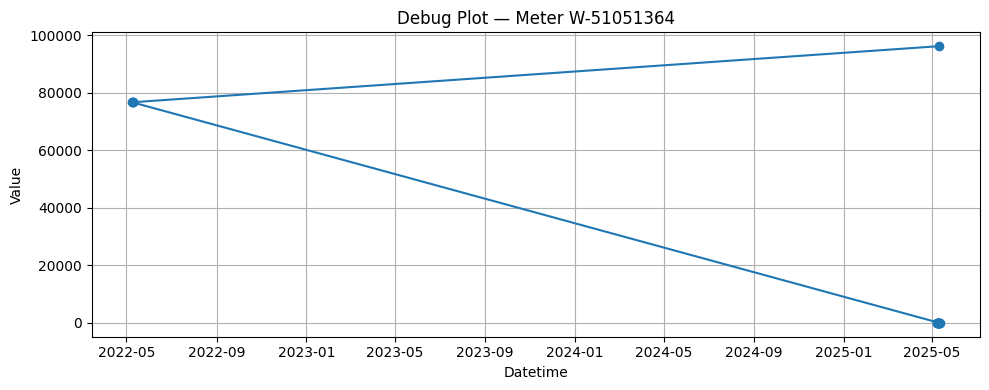

📈 Debug plot saved: meter_plots/meter_W-51051364.png


In [31]:
# ===== DEBUGGING PLOT FOR A SPECIFIC METER =====
# Define the meter ID to debug
target_meter_id = "W-122504526"  # Change as needed
#target_meter_id = input("Enter meter ID to debug: W-#########").strip()

# Optional: create plot folder
plot_output_dir = "meter_plots"
os.makedirs(plot_output_dir, exist_ok=True)

# Filter data for the specific meter
debug_group = full_df_unique[full_df_unique['meter_id'] == target_meter_id]

if debug_group.empty:
    print(f"⚠️ No data found for meter_id '{target_meter_id}'")
else:
    plt.figure(figsize=(10, 4))
    plt.plot(debug_group['datetime'], debug_group['value'], marker='o', linestyle='-')
    plt.title(f"Debug Plot — Meter {target_meter_id}")
    plt.xlabel("Datetime")
    plt.ylabel("Value")
    plt.grid(True)
    plt.tight_layout()

    # Save plot
    plot_path = os.path.join(plot_output_dir, f"meter_{target_meter_id}.png")
    plt.savefig(plot_path)
    plt.show()
    plt.close()
    print(f"📈 Debug plot saved: {plot_path}")

In [32]:
debug_group.head(13)

,datetime,meter_id,value
423498,2025-05-08 16:00:00,W-51051364,0.00
369228,2025-05-08 08:00:00,W-51051364,0.00
788294,2025-05-10 08:00:00,W-51051364,0.00
717466,2025-05-10 00:00:00,W-51051364,0.00
663237,2025-05-09 16:00:00,W-51051364,0.00
479258,2025-05-09 00:00:00,W-51051364,0.00
928214,2025-05-10 16:00:00,W-51051364,0.00
1226045,2025-05-11 16:00:00,W-51051364,0.00
1071243,2025-05-11 08:00:00,W-51051364,0.00
54825,2022-05-09 00:00:00,W-51051364,76661.95


Step 8.0 Scan Database and generate list of MeterID (unique only), save the list

In [33]:
# Extract unique meter IDs
meter_ids = full_df_unique['meter_id'].unique()

# Save to a file (one per line, text file)
with open('saved_meter_ids.txt', 'w') as f:
    for meter_id in meter_ids:
        f.write(f"{meter_id}\n")


Step 9.0 For each meter in the list, sort that meter's data by date-time, chronologically increase (old to new);
provide option to plot that sorted data Datetime on x-axis, Value on y-axis.  (as a function for reuse)

In [39]:
import os
import time
import matplotlib.pyplot as plt

def sort_and_optionally_plot_resumable(
    full_df, 
    meter_ids, 
    plot=False, 
    plot_dir="plots", 
    log_file="processed_ids.txt", 
    max_duration_seconds=300
):
    """
    Sorts and optionally plots time-series data for each meter_id.
    Logs progress to allow safe resumption and respects a time limit.
    
    Parameters:
    - full_df: DataFrame with ['meter_id', 'datetime', 'value']
    - meter_ids: list of meter IDs to process
    - plot: Boolean, if True plots are saved
    - plot_dir: Directory for saving plots
    - log_file: File to track processed meter_ids
    - max_duration_seconds: Max time in seconds to run the loop
    """
    
    # Create plot directory if needed
    if plot and not os.path.exists(plot_dir):
        os.makedirs(plot_dir)

    # Create log file if it doesn't exist
    if not os.path.exists(log_file):
        open(log_file, 'w').close()

    # Load already processed IDs
    with open(log_file, 'r') as f:
        processed_ids = set(line.strip() for line in f)

    meter_data_dict = {}
    start_time = time.time()

    for meter_id in meter_ids:
        if meter_id in processed_ids:
            continue  # Skip already done

        elapsed_time = time.time() - start_time
        if elapsed_time > max_duration_seconds:
            print(f"⏱️ Time limit of {max_duration_seconds}s reached. Stopping early.")
            break

        # Process the meter_id
        df_meter = full_df[full_df['meter_id'] == meter_id].copy()
        df_meter.sort_values(by='datetime', inplace=True)
        df_meter.reset_index(drop=True, inplace=True)
        meter_data_dict[meter_id] = df_meter

        # Plot if requested
        if plot:
            plt.figure(figsize=(10, 4))
            plt.plot(df_meter['datetime'], df_meter['value'], marker='o', linestyle='-')
            plt.title(f"Meter {meter_id} – Time Series")
            plt.xlabel("Datetime")
            plt.ylabel("Value")
            plt.grid(True)
            plt.tight_layout()
            plt.savefig(f"{plot_dir}/meter_{meter_id}.png")
            plt.close()

        # Log as processed
        with open(log_file, 'a') as f:
            f.write(f"{meter_id}\n")

    return meter_data_dict


In [44]:
# Will skip already-processed meters and keep going
sorted_meter_data = sort_and_optionally_plot_resumable(
    full_df_unique,
    meter_ids,
    plot=False,
    max_duration_seconds=60
)


⏱️ Time limit of 60s reached. Stopping early.


In [50]:
import time

def controlled_processing_loop(interval_on=60, interval_off=240, cycles=10):
    for cycle in range(cycles):
        print(f"🔄 Cycle {cycle+1}/{cycles} – Processing...")
        
        # Run for one minute
        sorted_meter_data = sort_and_optionally_plot_resumable(
            full_df_unique,
            meter_ids,
            plot=False,
            max_duration_seconds=interval_on
        )

        # Save state
#        with open("meter_data_dict.pkl", "wb") as f:
#            pickle.dump(sorted_meter_data, f)

        print(f"⏸️ Cooling off for {interval_off} seconds...\n")
        time.sleep(interval_off)


In [51]:
# Tool to respect AWS burstable CPU credits and maintaining forward progress without triggering throttling penalties.
controlled_processing_loop(interval_on=60, interval_off=240, cycles=1)

🔄 Cycle 1/1 – Processing...
⏱️ Time limit of 60s reached. Stopping early.
⏸️ Cooling off for 240 seconds...



Step 10.0 function to identify potential leaks; variables are small_value_threshold, default 1, small_value_contiguous_range, default 3., small_value_deviation  Function scans meter data, if finds a range of values within 1 sd of small value threshold then return something.

In [41]:
def detect_potential_leaks(
    meter_data_dict,
    small_value_threshold=1.0,
    small_value_contiguous_range=3,
    small_value_deviation=0.1,
    output_file="leak_messages.txt"
):
    """
    Scans each meter's time series to detect potential leaks.
    
    Parameters:
    - meter_data_dict: dict of {meter_id: sorted DataFrame}
    - small_value_threshold: baseline value indicating potential leak
    - small_value_contiguous_range: minimum sequence length to consider
    - small_value_deviation: max deviation from threshold for values to be "small"
    - output_file: filename to save messages

    Returns:
    - leaky_meter_ids: list of meter_ids with potential leaks
    """

    leak_messages = []
    leaky_meter_ids = []

    for meter_id, df in meter_data_dict.items():
        values = df['value'].values
        n = len(values)
        if n < small_value_contiguous_range:
            continue  # too short to test

        # Define test range
        lower = small_value_threshold - small_value_deviation
        upper = small_value_threshold + small_value_deviation

        # Track runs of small values
        count = 0
        for i, v in enumerate(values):
            if lower <= v <= upper:
                count += 1
                if count >= small_value_contiguous_range:
                    msg = f"Meter {meter_id} may have a leak: {count} consecutive values near {small_value_threshold}"
                    leak_messages.append(msg)
                    leaky_meter_ids.append(meter_id)
                    break  # One match is enough
            else:
                count = 0  # reset on break

    # Save to file
    with open(output_file, 'w') as f:
        for msg in leak_messages:
            f.write(msg + '\n')

    return leaky_meter_ids


In [42]:
leaky_meters = detect_potential_leaks(
    meter_data_dict=sorted_meter_data,
    small_value_threshold=1.0,
    small_value_contiguous_range=3,
    small_value_deviation=0.1,
    output_file="leak_messages.txt"
)


Step 11.0 Same for sudden high values changes, sudden_change_threshold, sudden_change_deviation?, Function scans, if finds suitable value, then return data for that change